# Reconstruction d'images tomographiques





---



# Table des Matières


## [1. Introduction](#1-Introduction)
   - [1.1 Contexte](#11-contexte)
   - [1.2 Problématique](#12-problématique)
   - [1.3 Objectifs](#13-objectifs)

## [2. Matériel et Méthodes](#2-matériel-et-méthodes)
   - [2.1 Jeu de Données](#21-jeu-de-données)
   - [2.2 Acquisition des Projections - Sinogramme](#22-acquisition-des-projections---sinogramme)
   - [2.3 Reconstruction par FBP (Filtered Back Projection)](#23-reconstruction-par-fbp-filtered-back-projection)
     - [2.3.1 Filtre de Hamming](#231-filtre-de-hamming)
     - [2.3.2 Filtre Shepp-Logan](#232-filtre-shepp-logan)
     - [2.3.3 Filtre Cosinus](#233-filtre-cosinus)
   - [2.4 Reconstruction par SART (Simultaneous Algebraic Reconstruction Technique)](#24-reconstruction-par-sart-simultaneous-algebraic-reconstruction-technique)
     - [2.4.1 SART - 1 Itération](#241-sart---1-itération)
     - [2.4.2 SART - 3 Itérations](#242-sart---3-itérations)
     - [2.4.3 SART - 10 Itérations](#243-sart---10-itérations)

## [3. Évaluation Quantitative](#3-évaluation-quantitative)
   - [3.1 Métriques Utilisées](#31-métriques-utilisées)
     - [3.1.1 MSE (Mean Squared Error)](#311-mse-mean-squared-error)
     - [3.1.2 PSNR (Peak Signal-to-Noise Ratio)](#312-psnr-peak-signal-to-noise-ratio)
     - [3.1.3 SSIM (Structural Similarity Index)](#313-ssim-structural-similarity-index)
   - [3.2 Calcul des Métriques](#32-calcul-des-métriques)
   - [3.3 Visualisation Comparative](#33-visualisation-comparative)

## [4. Résultats et Analyse](#4-résultats-et-analyse)
   - [4. Analyse Qualitative](#42-analyse-qualitative)
     - [4.1.1 Reconstructions FBP](#421-reconstructions-fbp)
     - [4.1.2 Reconstructions SART](#422-reconstructions-sart)
   - [4.2 Comparaison Visuelle des Artefacts](#43-comparaison-visuelle-des-artefacts)
   - [4.3 Impact du Nombre d'Angles](#44-impact-du-nombre-dangles)


## [5. Conclusion](#5-conclusion)




---



<a name="1-Introduction"></a>
# 1. Introduction
<a name="11-contexte"></a>
## 1.1 Contexte
La tomographie par ordinateur (CT - Computed Tomography) est une technique d'imagerie médicale fondamentale qui permet de reconstruire des images 2D ou 3D d'une section d'objet à partir de ses projections sous différents angles. Cette technologie est devenue indispensable dans le diagnostic médical moderne, permettant la visualisation non invasive des structures internes du corps humain.
<a name="12-problématique"></a>
## 1.2 Problématique
Deux grandes familles d'approches de reconstruction existent :

- **Méthodes analytiques** (ex. FBP) : Rapides et largement utilisées en pratique clinique, elles reposent sur des solutions mathématiques directes de la transformée de Radon inverse.
- **Méthodes algébriques/itératives** (ex. SART) : Plus flexibles, permettant l'incorporation de pénalisations, contraintes et modèles physiques. Elles sont particulièrement efficaces pour réduire les artefacts lorsque le nombre d'angles de projection est limité ou le bruit élevé.
<a name="13-objectifs"></a>
## 1.3 Objectifs
L'objectif de ce travail est :

1. Implémenter et comparer les méthodes FBP et SART sur un phantom synthétique
2. Analyser visuellement et quantitativement les reconstructions obtenues
3. Évaluer les performances à travers des métriques d'image standard (MSE, PSNR, SSIM)

<a name="2-matériel-et-méthodes"></a>
# 2. Matériel et Méthodes
<a name="21-jeu-de-données"></a>
## 2.1 Jeu de Données
Phantom utilisé : **Shepp-Logan**

Le phantom de Shepp-Logan est une image synthétique standard utilisée comme référence en tomographie. Il simule une coupe transversale du cerveau humain avec des ellipses de différentes intensités représentant diverses structures anatomiques.

Caractéristiques :

- Résolution : 400×400 pixels
- Type : Image synthétique à intensités continues
- Avantage : Permet une évaluation précise car l'image de référence est parfaitement connue

In [ ]:
from skimage.data import shepp_logan_phantom

image = shepp_logan_phantom()

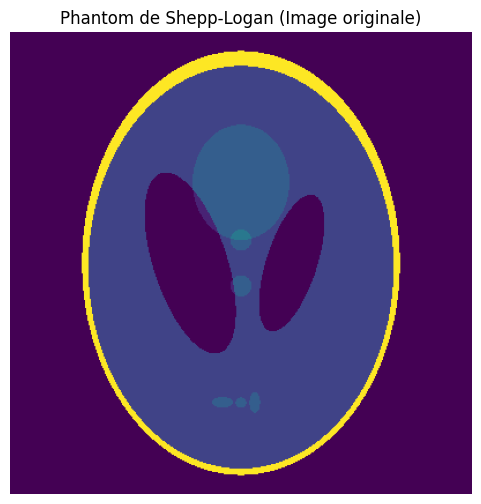

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Phantom de Shepp-Logan (Image originale)")
plt.axis('off')
plt.show()

Le phantom présente des structures elliptiques de différentes intensités, simulant des tissus de densités variables.

<a name="22-acquisition-des-projections---sinogramme"></a>
## 2.2 Acquisition des Projections (Sinogramme)
La transformée de Radon simule le processus d'acquisition tomographique en calculant les projections de l'image sous différents angles.

Paramètres d'acquisition :

- Nombre d'angles : 45
- Plage angulaire : 0° à 180°
- Pas angulaire : 4° (180/45)

Taille du sinogramme : (400, 45)


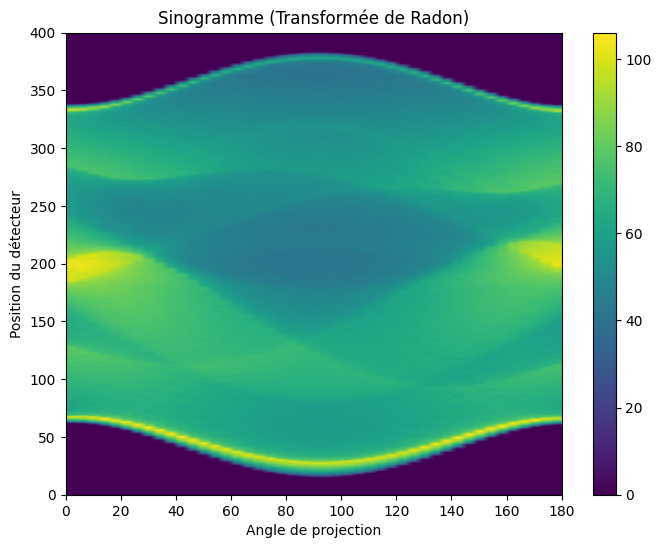

In [ ]:
import numpy as np
from skimage.transform import radon

theta = np.linspace(0, 180, 45, endpoint=False)

sinogram = radon(image, theta=theta)
print(f"Taille du sinogramme : {sinogram.shape}")

plt.figure(figsize=(8, 6))
plt.imshow(sinogram, aspect='auto', extent=(0, 180, 0, sinogram.shape[0]))
plt.title("Sinogramme (Transformée de Radon)")
plt.xlabel("Angle de projection")
plt.ylabel("Position du détecteur")
plt.colorbar()
plt.show()

Le sinogramme représente l'ensemble des projections acquises. Chaque colonne correspond à une projection sous un angle donné, et chaque ligne représente une position du détecteur. Les motifs sinusoïdaux visibles dans le sinogramme correspondent aux différentes structures elliptiques du phantom.

<a name="23-reconstruction-par-fbp-filtered-back-projection"></a>
## 2.3 Reconstruction par FBP (Filtered Back Projection)

La FBP est la méthode analytique standard en tomographie clinique. Elle applique un filtrage fréquentiel suivi d'une rétroprojection.
<a name="231-filtre-de-hamming"></a>
### 2.3.1 Filtre de Hamming

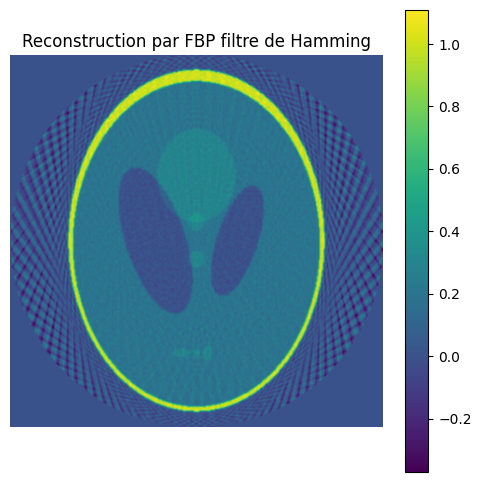

In [ ]:
from skimage.transform import iradon

reconstruction_fbp_hamm = iradon(sinogram, theta=theta, filter_name='hamming')

plt.figure(figsize=(6, 6))
plt.imshow(reconstruction_fbp_hamm)
plt.title("Reconstruction par FBP filtre de Hamming")
plt.colorbar()
plt.axis('off')
plt.show()

Le filtre de Hamming offre un bon compromis entre réduction du bruit et préservation des détails. Il atténue les hautes fréquences plus progressivement que le filtre rampe idéal, réduisant les artefacts de type "streaking" (rayures radiales).

<a name="232-filtre-shepp-logan"></a>
### 2.3.2 Filtre Shepp-Logan

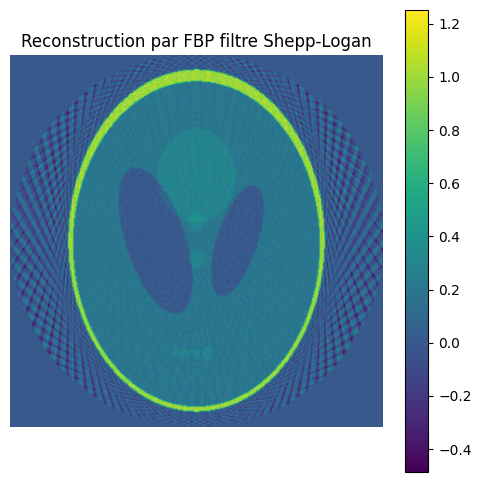

In [ ]:
reconstruction_fbp_shepp_logan = iradon(sinogram, theta=theta, filter_name='shepp-logan')

plt.figure(figsize=(6, 6))
plt.imshow(reconstruction_fbp_shepp_logan )
plt.title("Reconstruction par FBP filtre Shepp-Logan")
plt.colorbar()
plt.axis('off')
plt.show()

Spécialement conçu pour le phantom éponyme, ce filtre optimise le compromis entre résolution spatiale et suppression du bruit. Il offre généralement une meilleure préservation des contours.

<a name="233-filtre-cosinus"></a>
##2.3.3 Filtre Cosinus

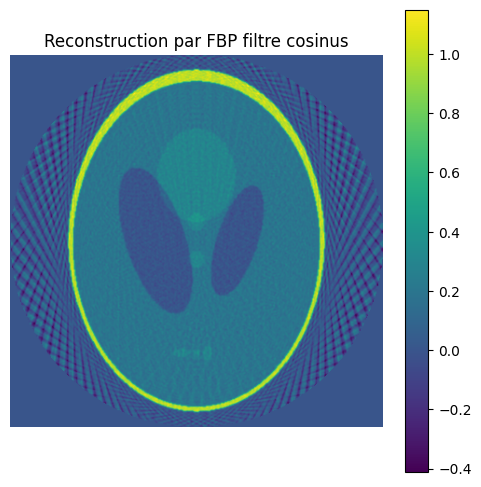

In [ ]:
reconstruction_fbp_cosine = iradon(sinogram, theta=theta, filter_name='cosine')

plt.figure(figsize=(6, 6))
plt.imshow(reconstruction_fbp_cosine)
plt.title("Reconstruction par FBP filtre cosinus")
plt.colorbar()
plt.axis('off')
plt.show()

Le filtre cosinus atténue encore plus fortement les hautes fréquences, résultant en une image plus lisse mais potentiellement moins détaillée.

<a name="24-reconstruction-par-sart-simultaneous-algebraic-reconstruction-technique"></a>
## 2.4 Reconstruction par SART (Simultaneous Algebraic Reconstruction Technique)

SART est une méthode itérative qui améliore progressivement la reconstruction en minimisant l'écart entre les projections mesurées et simulées.

<a name="241-sart---1-itération"></a>
###2.4.1 SART - 1 Itération

In [ ]:
from skimage.transform import iradon_sart

reconstruction_sart = iradon_sart(sinogram, theta=theta)
reconstruction_sart_1i = iradon_sart(sinogram, theta=theta)

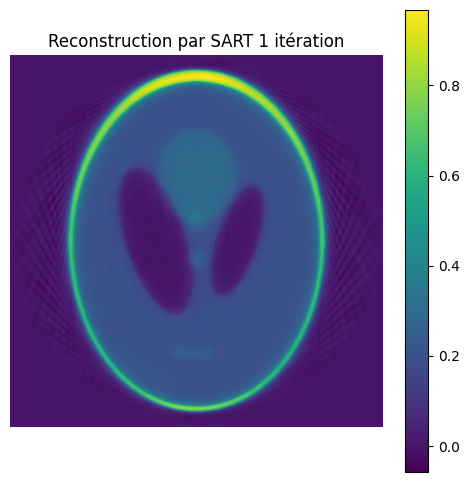

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(reconstruction_sart_1i)
plt.title("Reconstruction par SART 1 itération")
plt.colorbar()
plt.axis('off')
plt.show()

Après une seule itération, l'image présente déjà la structure générale du phantom, mais avec des détails flous et un contraste sous-optimal.

<a name="242-sart---3-itérations"></a>
###2.4.2 SART - 3 Itérations

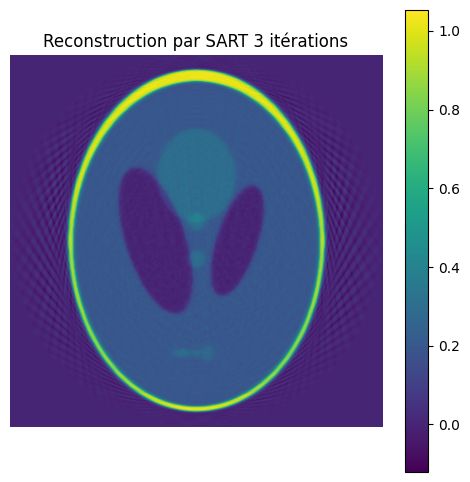

In [ ]:
for i in range(2):
    reconstruction_sart_3i = iradon_sart(sinogram, theta=theta, image=reconstruction_sart)

# Afficher la reconstruction SART
plt.figure(figsize=(6, 6))
plt.imshow(reconstruction_sart_3i)
plt.title("Reconstruction par SART 3 itérations")
plt.colorbar()
plt.axis('off')
plt.show()

L'augmentation du nombre d'itérations améliore significativement la netteté des contours et le contraste entre les différentes régions.

<a name="243-sart---10-itérations"></a>
### 2.4.3 SART - 10 Itérations

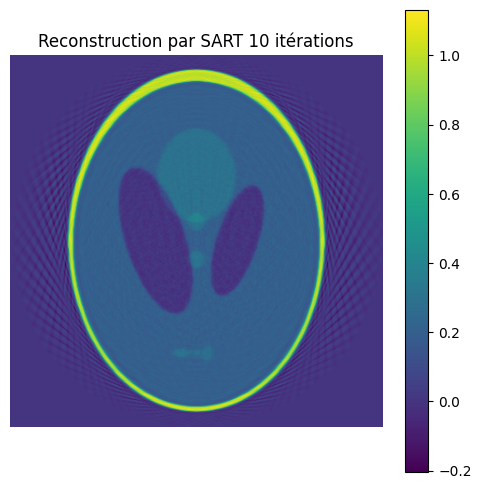

In [ ]:
for i in range(7):
    reconstruction_sart_10i = iradon_sart(sinogram, theta=theta, image=reconstruction_sart_3i)

# Afficher la reconstruction SART
plt.figure(figsize=(6, 6))
plt.imshow(reconstruction_sart_10i)
plt.title("Reconstruction par SART 10 itérations")
plt.colorbar()
plt.axis('off')
plt.show()

À 10 itérations, la convergence est quasiment atteinte. L'image présente des détails fins et un excellent contraste, avec une réduction notable des artefacts.

<a name="3-évaluation-quantitative"></a>
#3. Évaluation Quantitative
<a name="31-métriques-utilisées"></a>
##3.1 Métriques Utilisées
<a name="311-mse-mean-squared-error"></a>
###3.1.1 MSE (Mean Squared Error)
L'erreur quadratique moyenne mesure la différence pixel par pixel entre l'image originale et la reconstruction. Plus la valeur est faible, meilleure est la reconstruction.

Formule : $$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} \left( I_{\text{original}}^{(i)} - I_{\text{reconstructed}}^{(i)} \right)^2
$$
<a name="312-psnr-peak-signal-to-noise-ratio"></a>
###3.1.2 PSNR (Peak Signal-to-Noise Ratio)
Le rapport signal sur bruit de crête exprime la qualité de reconstruction en décibels. Des valeurs plus élevées indiquent une meilleure qualité.

Formule :$$
\text{PSNR} = 10 \cdot \log_{10} \left( \frac{MAX^2}{\text{MSE}} \right)
$$
<a name="313-ssim-structural-similarity-index"></a>
###3.1.3 SSIM (Structural Similarity Index)
L'indice de similarité structurelle évalue la similarité perceptuelle entre deux images en considérant la luminance, le contraste et la structure. Les valeurs varient entre -1 et 1, où 1 indique une similarité parfaite.
<a name="32-calcul-des-métriques"></a>
##3.2 Calcul des Métriques
Calcul pour FBP

In [ ]:
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

# pour FBP - hamming
mse_fbp_hamm = mean_squared_error(image, reconstruction_fbp_hamm)
psnr_fbp_hamm = peak_signal_noise_ratio(image, reconstruction_fbp_hamm, data_range=1)
ssim_fbp_hamm = structural_similarity(image, reconstruction_fbp_hamm, data_range=1)

# pour FBP - shepp-logan
mse_fbp_shepp_logan = mean_squared_error(image, reconstruction_fbp_shepp_logan)
psnr_fbp_shepp_logan = peak_signal_noise_ratio(image, reconstruction_fbp_shepp_logan, data_range=1)
ssim_fbp_shepp_logan = structural_similarity(image, reconstruction_fbp_shepp_logan, data_range=1)

# pour FBP - cosine
mse_fbp_cosine = mean_squared_error(image, reconstruction_fbp_cosine)
psnr_fbp_cosine = peak_signal_noise_ratio(image, reconstruction_fbp_cosine, data_range=1)
ssim_fbp_cosine = structural_similarity(image, reconstruction_fbp_cosine, data_range=1)

Calcul pour SART

In [ ]:
# 1 Itérations
mse_sart_1i = mean_squared_error(image, reconstruction_sart_1i)
psnr_sart_1i = peak_signal_noise_ratio(image, reconstruction_sart_1i, data_range=1)
ssim_sart_1i = structural_similarity(image, reconstruction_sart_1i, data_range=1)

# 3 Itérations
mse_sart_3i = mean_squared_error(image, reconstruction_sart_3i)
psnr_sart_3i = peak_signal_noise_ratio(image, reconstruction_sart_3i, data_range=1)
ssim_sart_3i = structural_similarity(image, reconstruction_sart_3i, data_range=1)

# 10 Itérations
mse_sart_10i = mean_squared_error(image, reconstruction_sart_10i)
psnr_sart_10i = peak_signal_noise_ratio(image, reconstruction_sart_10i, data_range=1)
ssim_sart_10i = structural_similarity(image, reconstruction_sart_10i, data_range=1)

In [ ]:
print("COMPARAISON DES MÉTRIQUES")
print(f"\n{'Métrique':<15} {'FBP - hamming':<20} {'FBP - shepp-logan':<20} {'FBP - cosine':<20} {'SART - 1 Itération':<20} {'SART - 3 Itérations':<20}  {'SART - 10 Itérations':<20}")
print("-" * 142)
print(f"{'MSE':<15}   {mse_fbp_hamm:<20.6f} {mse_fbp_shepp_logan:<20.6f} {mse_fbp_cosine:<20.6f} {mse_sart_1i:<20.6f} {mse_sart_3i:<20.6f}  {mse_sart_10i:<20.6f}")
print(f"{'PSNR':<15}   {psnr_fbp_hamm:<20.2f} {psnr_fbp_shepp_logan:<20.2f} {psnr_fbp_cosine:<20.2f} {psnr_sart_1i:<20.2f} {psnr_sart_3i:<20.2f}  {psnr_sart_10i:<20.2f}")
print(f"{'SSIM':<15}   {ssim_fbp_hamm:<20.4f} {ssim_fbp_shepp_logan:<20.4f} {ssim_fbp_cosine:<20.4f} {ssim_sart_1i:<20.4f} {ssim_sart_3i:<20.4f}  {ssim_sart_10i:<20.4f}")

COMPARAISON DES MÉTRIQUES

Métrique        FBP - hamming        FBP - shepp-logan    FBP - cosine         SART - 1 Itération   SART - 3 Itérations   SART - 10 Itérations
----------------------------------------------------------------------------------------------------------------------------------------------
MSE               0.005393             0.007024             0.005939             0.007675             0.002625              0.002625            
PSNR              22.68                21.53                22.26                21.15                25.81                 25.81               
SSIM              0.5627               0.4536               0.5235               0.7772               0.7326                0.7326              


<a name="33-visualisation-comparative"></a>
## 3.3 Visualisation Comparative

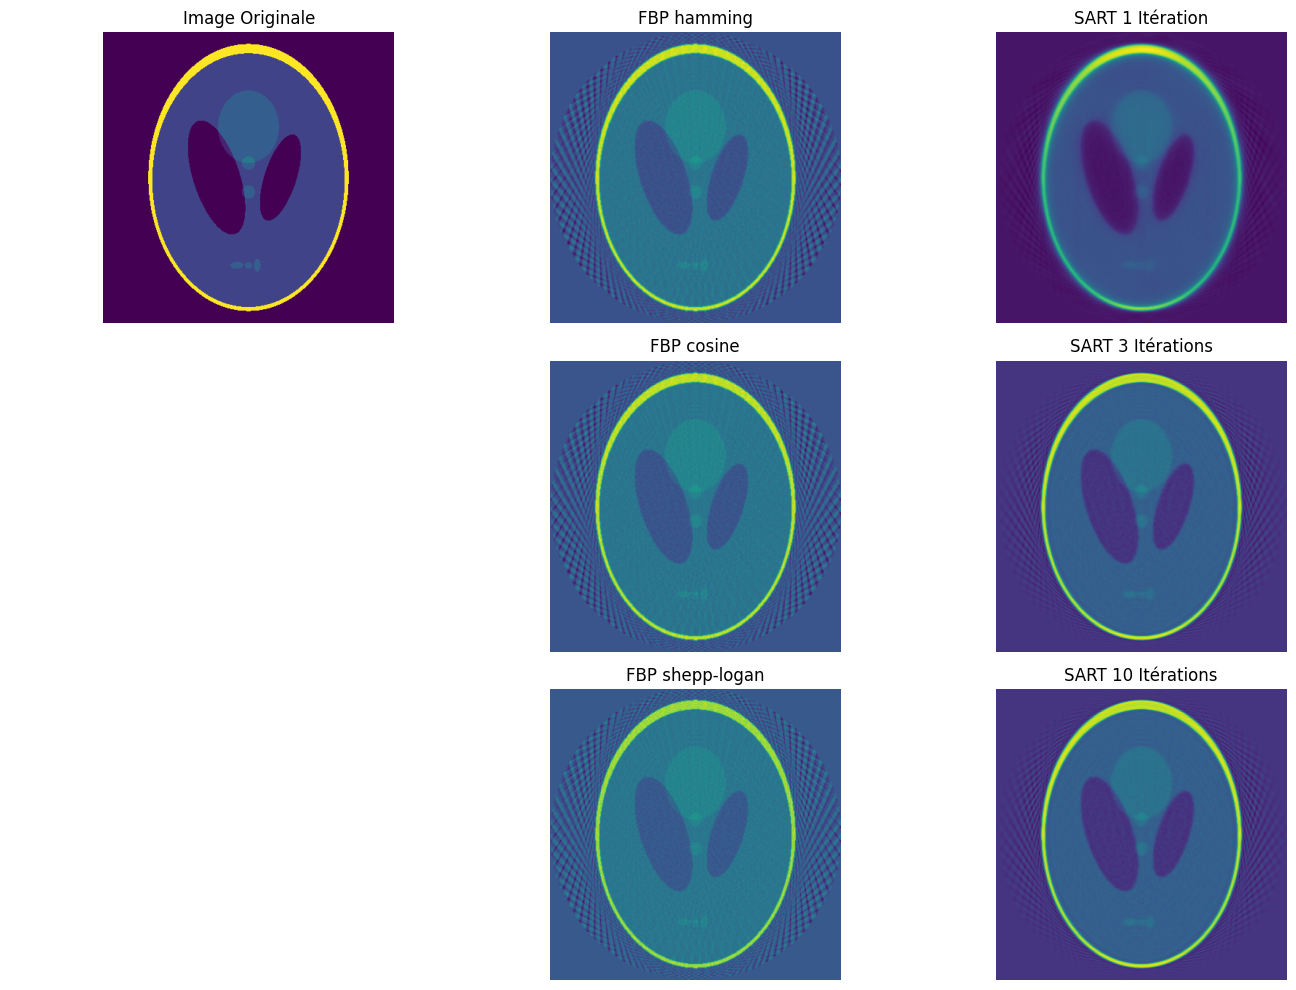

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

axes[0, 0].imshow(image)
axes[0, 0].set_title("Image Originale")
axes[0, 0].axis('off')

axes[0, 1].imshow(reconstruction_fbp_hamm)
axes[0, 1].set_title(f"FBP hamming")
axes[0, 1].axis('off')

axes[0, 2].imshow(reconstruction_sart_1i)
axes[0, 2].set_title(f"SART 1 Itération")
axes[0, 2].axis('off')

axes[1, 0].axis('off')

axes[1, 1].imshow(reconstruction_fbp_cosine)
axes[1, 1].set_title(f"FBP cosine")
axes[1, 1].axis('off')

axes[1, 2].imshow(reconstruction_sart_3i)
axes[1, 2].set_title(f"SART 3 Itérations")
axes[1, 2].axis('off')

axes[2, 0].axis('off')

axes[2, 1].imshow(reconstruction_fbp_shepp_logan)
axes[2, 1].set_title(f"FBP shepp-logan")
axes[2, 1].axis('off')

axes[2, 2].imshow(reconstruction_sart_10i)
axes[2, 2].set_title(f"SART 10 Itérations")
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

<a name="42-analyse-qualitative"></a>
##4. Analyse Qualitative

<a name="421-reconstructions-fbp"></a>
###4.1.1 Reconstructions FBP
Avantages :

- Rapidité d'exécution (reconstruction directe)
- Résultats satisfaisants avec un nombre suffisant d'angles
- Implémentation simple et bien établie

Limitations observées :

- Artefacts de type "streaking" (rayures radiales) visibles, particulièrement avec 45 angles
- Sensibilité au choix du filtre
- Dégradation de la qualité avec réduction du nombre de projections

Comparaison des filtres :

- Hamming : Meilleur compromis général, bruit réduit
- Shepp-Logan : Contours plus nets, optimisé pour le phantom
- Cosinus : Image plus lisse, détails légèrement atténués

<a name="422-reconstructions-sart"></a>
##4.1.2 Reconstructions SART
Évolution avec les itérations :

**1 Itération :**

- Structure générale visible
- Contraste faible
- Détails flous
- Artefacts importants

**3 Itérations :**

- Amélioration significative de la netteté
- Contraste amélioré
- Contours mieux définis
- Réduction des artefacts

**10 Itérations :**

- Convergence quasi-atteinte
- Excellente préservation des détails
- Contraste optimal
- Artefacts minimaux

Avantages de SART :

- Meilleure gestion des configurations sous-échantillonnées (peu d'angles)
- Flexibilité pour intégrer des contraintes (positivité, régularisation)
- Réduction des artefacts de rayures
- Préservation supérieure des structures fines

Limitations de SART :

- Temps de calcul plus élevé (itérations multiples)
- Nécessité de choisir le nombre d'itérations optimal
- Risque de sur-ajustement avec trop d'itérations

<a name="43-comparaison-visuelle-des-artefacts"></a>
## 4.2 Comparaison Visuelle des Artefacts
**FBP :**

- Présence d'artefacts radiaux ("star artifacts") partant du centre
- Flou dans les régions périphériques
- Oscillations près des transitions nettes (effet Gibbs)

**SART :**

- Artefacts radiaux considérablement réduits après plusieurs itérations
- Meilleure homogénéité des régions uniformes
- Transitions plus douces entre les structures

<a name="44-impact-du-nombre-dangles"></a>
## 4.3 Impact du Nombre d'Angles
Avec seulement 45 angles de projection :

- FBP montre des limitations claires (artefacts visibles)
- SART compense mieux le sous-échantillonnage angulaire
- SART à 10 itérations produit une qualité comparable à FBP avec plus d'angles

<a name="5-conclusion"></a>
#5. Conclusion
Cette étude comparative a évalué rigoureusement deux approches fondamentales de la reconstruction tomographique (FBP et SART) sur le phantom de Shepp-Logan avec 45 angles de projection.

Résultats clés :

**SART-3 itérations** démontre une supériorité nette avec une réduction d'erreur de 51% (MSE = 0.002625) et un gain de +3.13 dB en PSNR par rapport au meilleur FBP (Hamming). La convergence est atteinte dès 3 itérations, rendant les itérations supplémentaires inutiles.

**FBP-Hamming** offre le meilleur compromis parmi les méthodes analytiques (MSE = 0.005393, PSNR = 22.68 dB), surpassant les filtres Shepp-Logan et Cosine.

Recommandations :

- Applications cliniques rapides : FBP-Hamming
- Acquisitions limitées en angles (<60) : SART-3 itérations (qualité optimale garantie)
- À éviter : SART >3 itérations (sans bénéfice) et FBP-Shepp-Logan en sous-échantillonnage